# Assignment 2: Mastering Big Data Handling
**Course:** SECP3133 High Performance Data Processing  
**Dataset:** Airline Delay and Cancellation Data, 2018  
**Libraries:** Pandas (Baseline) | Dask | Polars  
**Platform:** Google Colab + GitHub

---
## 0. Environment Setup
Install and import all required libraries. Run this cell first at the start of every Colab session.

In [ ]:
# Install libraries not pre-installed in Colab
!pip install -q dask polars memory_profiler

In [5]:
# ── Core libraries ──────────────────────────────────────────────
import pandas as pd
import dask
import polars as pl

# ── Performance measurement ──────────────────────────────────────
import time
import tracemalloc

# ── Visualisation ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings

# ── Utilities ───────────────────────────────────────────────────
import os
import gc

warnings.filterwarnings('ignore')
print('All libraries imported successfully.')
print(f'Pandas  : {pd.__version__}')
print(f'Dask    : {dask.__version__}')
print(f'Polars  : {pl.__version__}')

All libraries imported successfully.
Pandas  : 2.2.2
Dask    : 2026.6.0
Polars  : 1.35.2


### Mount Google Drive
Upload the dataset to your Google Drive first, then mount it here so data persists across sessions.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# ── Set path to the dataset file ────────────────────────────────
# We use the 2018 CSV (~700 MB) as our primary working file.
# Adjust the path below if your Drive folder is different.
DATA_PATH = '/content/drive/MyDrive/2018.csv'

# Verify the file exists and show its size
size_bytes = os.path.getsize(DATA_PATH)
size_mb    = size_bytes / (1024 ** 2)
print(f'File found: {DATA_PATH}')
print(f'File size : {size_mb:.1f} MB')

Mounted at /content/drive
File found: /content/drive/MyDrive/2018.csv
File size : 851.6 MB


---
## Task 2: Load and Inspect Data
We first load the dataset using Pandas to understand its structure before applying any optimisation. This gives us a baseline understanding of the data.

In [7]:
# ── Initial load (no optimisation — baseline inspection only) ───
# We load a small sample of 50,000 rows purely for inspection so
# we do not exhaust Colab RAM at this stage.

print('Loading first 50,000 rows for inspection...')
df_inspect = pd.read_csv(DATA_PATH, nrows=50_000)

print(f'\nShape  : {df_inspect.shape[0]:,} rows × {df_inspect.shape[1]} columns')

Loading first 50,000 rows for inspection...

Shape  : 50,000 rows × 28 columns


In [8]:
# ── Column names and data types ──────────────────────────────────
print('Column names and default dtypes:\n')
print(df_inspect.dtypes.to_string())

Column names and default dtypes:

FL_DATE                 object
OP_CARRIER              object
OP_CARRIER_FL_NUM        int64
ORIGIN                  object
DEST                    object
CRS_DEP_TIME             int64
DEP_TIME               float64
DEP_DELAY              float64
TAXI_OUT               float64
WHEELS_OFF             float64
WHEELS_ON              float64
TAXI_IN                float64
CRS_ARR_TIME             int64
ARR_TIME               float64
ARR_DELAY              float64
CANCELLED              float64
CANCELLATION_CODE       object
DIVERTED               float64
CRS_ELAPSED_TIME       float64
ACTUAL_ELAPSED_TIME    float64
AIR_TIME               float64
DISTANCE               float64
CARRIER_DELAY          float64
WEATHER_DELAY          float64
NAS_DELAY              float64
SECURITY_DELAY         float64
LATE_AIRCRAFT_DELAY    float64
Unnamed: 27            float64


In [9]:
# ── Missing value summary ────────────────────────────────────────
missing = df_inspect.isnull().sum()
missing_pct = (missing / len(df_inspect) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing values per column:')
print(missing_df[missing_df['Missing Count'] > 0].to_string())

Missing values per column:
                     Missing Count  Missing %
DEP_TIME                       977       1.95
DEP_DELAY                     1049       2.10
TAXI_OUT                       999       2.00
WHEELS_OFF                     999       2.00
WHEELS_ON                     1025       2.05
TAXI_IN                       1025       2.05
ARR_TIME                      1025       2.05
ARR_DELAY                     1118       2.24
CANCELLATION_CODE            48993      97.99
ACTUAL_ELAPSED_TIME           1094       2.19
AIR_TIME                      1094       2.19
CARRIER_DELAY                36724      73.45
WEATHER_DELAY                36724      73.45
NAS_DELAY                    36724      73.45
SECURITY_DELAY               36724      73.45
LATE_AIRCRAFT_DELAY          36724      73.45
Unnamed: 27                  50000     100.00


In [10]:
# ── Preview first 5 rows ────────────────────────────────────────
print('First 5 rows of the dataset:')
df_inspect.head()

First 5 rows of the dataset:


,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,...,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
0,2018-01-01,UA,2429,EWR,DEN,1517,1512.0,-5.0,15.0,1527.0,...,268.0,250.0,225.0,1605.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-01,UA,2427,LAS,SFO,1115,1107.0,-8.0,11.0,1118.0,...,99.0,83.0,65.0,414.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-01,UA,2426,SNA,DEN,1335,1330.0,-5.0,15.0,1345.0,...,134.0,126.0,106.0,846.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-01,UA,2425,RSW,ORD,1546,1552.0,6.0,19.0,1611.0,...,190.0,182.0,157.0,1120.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-01,UA,2424,ORD,ALB,630,650.0,20.0,13.0,703.0,...,112.0,106.0,83.0,723.0,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# ── Basic statistics ────────────────────────────────────────────
print('Descriptive statistics for numeric columns:')
df_inspect.describe().T

Descriptive statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
OP_CARRIER_FL_NUM,50000.0,2684.776820,2020.743374,1.0,856.0,2010.0,4520.0,7439.0
CRS_DEP_TIME,50000.0,1342.937260,500.574932,1.0,922.0,1331.0,1745.0,2359.0
DEP_TIME,49023.0,1356.864859,513.956465,1.0,931.0,1345.0,1800.0,2400.0
DEP_DELAY,48951.0,17.754224,53.407534,-49.0,-4.0,1.0,19.0,1752.0
TAXI_OUT,49001.0,17.497255,9.801251,1.0,11.0,15.0,21.0,124.0
WHEELS_OFF,49001.0,1378.473399,515.449005,1.0,945.0,1358.0,1814.0,2400.0
WHEELS_ON,48975.0,1462.923410,552.174980,1.0,1048.0,1510.0,1917.0,2400.0
TAXI_IN,48975.0,7.859071,6.644290,1.0,4.0,6.0,9.0,120.0
CRS_ARR_TIME,50000.0,1483.484480,536.558056,1.0,1100.0,1517.0,1923.0,2359.0
ARR_TIME,48975.0,1464.951751,558.090078,1.0,1051.0,1513.0,1921.0,2400.0


In [12]:
# Free memory before moving to strategy implementations
del df_inspect
gc.collect()
print('Inspection dataframe removed from memory.')

Inspection dataframe removed from memory.


---
## Task 3: Big Data Handling Strategies

We implement all five required strategies below. Each strategy includes:
1. An explanation of what it does and why
2. Working code with memory and/or time measurement
3. Output and discussion

### Strategy 1: Load Less Data (Select Columns)

**What:** Instead of reading all 28 columns, we load only the columns needed for our analysis.  
**Why:** Unused columns waste RAM. Specifying `usecols` reduces memory immediately at read time, before any data enters Python.  
**When:** Use this as the first step in any large-file workflow.

In [13]:
# Columns relevant to our delay analysis
SELECTED_COLS = [
    'FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DEST',
    'DEP_DELAY', 'ARR_DELAY', 'CANCELLED',
    'AIR_TIME', 'DISTANCE'
]

# ── Measure: full load vs selective load ─────────────────────────

# Full load
tracemalloc.start()
t0 = time.time()
df_full = pd.read_csv(DATA_PATH)
t_full  = time.time() - t0
_, mem_full = tracemalloc.get_traced_memory()
tracemalloc.stop()
mem_full_mb = mem_full / 1024**2

del df_full; gc.collect()

# Selective load
tracemalloc.start()
t0 = time.time()
df_selective = pd.read_csv(DATA_PATH, usecols=SELECTED_COLS)
t_selective  = time.time() - t0
_, mem_selective = tracemalloc.get_traced_memory()
tracemalloc.stop()
mem_selective_mb = mem_selective / 1024**2

print('=== Strategy 1: Load Less Data ===')
print(f'Full load    → Time: {t_full:.2f}s | Peak Memory: {mem_full_mb:.1f} MB')
print(f'Select cols  → Time: {t_selective:.2f}s | Peak Memory: {mem_selective_mb:.1f} MB')
print(f'Memory saved : {mem_full_mb - mem_selective_mb:.1f} MB '
      f'({(1 - mem_selective_mb/mem_full_mb)*100:.1f}% reduction)')
print(f'Rows loaded  : {len(df_selective):,}')
print(f'Columns kept : {len(df_selective.columns)} / originally 28+')

df_selective.head(3)

=== Strategy 1: Load Less Data ===
Full load    → Time: 56.59s | Peak Memory: 5289.8 MB
Select cols  → Time: 19.46s | Peak Memory: 997.1 MB
Memory saved : 4292.7 MB (81.1% reduction)
Rows loaded  : 7,213,446
Columns kept : 9 / originally 28+


,FL_DATE,OP_CARRIER,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE
0,2018-01-01,UA,EWR,DEN,-5.0,-23.0,0.0,225.0,1605.0
1,2018-01-01,UA,LAS,SFO,-8.0,-24.0,0.0,65.0,414.0
2,2018-01-01,UA,SNA,DEN,-5.0,-13.0,0.0,106.0,846.0


### Strategy 2: Chunking

**What:** Read the file in smaller pieces (chunks) and process each chunk individually.  
**Why:** At any point only one chunk lives in memory, allowing us to process files larger than available RAM.  
**When:** Use when the full file would exceed available memory, or when aggregating over the entire dataset.

In [14]:
CHUNK_SIZE = 200_000   # rows per chunk

tracemalloc.start()
t0 = time.time()

# Aggregate: compute total and average departure delay across chunks
total_delay  = 0
total_rows   = 0
chunks_read  = 0
peak_chunk_mem = 0

for chunk in pd.read_csv(DATA_PATH, usecols=SELECTED_COLS, chunksize=CHUNK_SIZE):
    # Drop rows with missing DEP_DELAY
    chunk = chunk.dropna(subset=['DEP_DELAY'])
    total_delay += chunk['DEP_DELAY'].sum()
    total_rows  += len(chunk)
    chunks_read += 1
    _, cur_mem = tracemalloc.get_traced_memory()
    peak_chunk_mem = max(peak_chunk_mem, cur_mem)

t_chunk = time.time() - t0
tracemalloc.stop()

avg_delay = total_delay / total_rows if total_rows > 0 else 0

print('=== Strategy 2: Chunking ===')
print(f'Chunk size   : {CHUNK_SIZE:,} rows')
print(f'Chunks read  : {chunks_read}')
print(f'Total rows   : {total_rows:,}')
print(f'Execution time  : {t_chunk:.2f} s')
print(f'Peak memory  : {peak_chunk_mem/1024**2:.1f} MB  (only 1 chunk in RAM at a time)')
print(f'Avg DEP_DELAY: {avg_delay:.2f} minutes')

=== Strategy 2: Chunking ===
Chunk size   : 200,000 rows
Chunks read  : 37
Total rows   : 7,096,212
Execution time  : 30.46 s
Peak memory  : 43.9 MB  (only 1 chunk in RAM at a time)
Avg DEP_DELAY: 9.97 minutes


### Strategy 3: Data Type Optimization

**What:** Convert columns to more memory-efficient data types (e.g., `float64` → `float32`, string → `category`).  
**Why:** Pandas assigns generous defaults (`int64`, `float64`, `object`) that are often wasteful. Downcasting can cut memory use by 50%+.  
**When:** Apply after initial inspection, before any heavy processing, so all subsequent operations benefit.

In [15]:
# Load with default types first to measure baseline
df_default = pd.read_csv(DATA_PATH, usecols=SELECTED_COLS)
mem_before = df_default.memory_usage(deep=True).sum() / 1024**2

print(f'Memory BEFORE optimisation: {mem_before:.1f} MB')
print('\nDefault dtypes:')
print(df_default.dtypes.to_string())

Memory BEFORE optimisation: 1747.3 MB

Default dtypes:
FL_DATE        object
OP_CARRIER     object
ORIGIN         object
DEST           object
DEP_DELAY     float64
ARR_DELAY     float64
CANCELLED     float64
AIR_TIME      float64
DISTANCE      float64


In [16]:
# ── Apply optimisation ──────────────────────────────────────────
df_optimised = df_default.copy()

# String/object columns with low cardinality → category
for col in ['OP_CARRIER', 'ORIGIN', 'DEST']:
    df_optimised[col] = df_optimised[col].astype('category')

# Float64 columns → float32 (values fit comfortably in 32-bit)
for col in ['DEP_DELAY', 'ARR_DELAY', 'AIR_TIME', 'DISTANCE']:
    df_optimised[col] = pd.to_numeric(df_optimised[col], errors='coerce').astype('float32')

# Boolean column (0/1) → bool
df_optimised['CANCELLED'] = df_optimised['CANCELLED'].astype('bool')

mem_after = df_optimised.memory_usage(deep=True).sum() / 1024**2
reduction = (1 - mem_after / mem_before) * 100

print(f'Memory AFTER  optimisation: {mem_after:.1f} MB')
print(f'Reduction     : {reduction:.1f}%')
print('\nOptimised dtypes:')
print(df_optimised.dtypes.to_string())

# Per-column breakdown
before_col = df_default.memory_usage(deep=True) / 1024**2
after_col  = df_optimised.memory_usage(deep=True) / 1024**2
comparison = pd.DataFrame({'Before (MB)': before_col, 'After (MB)': after_col}).drop('Index')
comparison['Saved (MB)'] = comparison['Before (MB)'] - comparison['After (MB)']
print('\nPer-column memory usage:')
print(comparison.round(3).to_string())

Memory AFTER  optimisation: 557.3 MB
Reduction     : 68.1%

Optimised dtypes:
FL_DATE         object
OP_CARRIER    category
ORIGIN        category
DEST          category
DEP_DELAY      float32
ARR_DELAY      float32
CANCELLED         bool
AIR_TIME       float32
DISTANCE       float32

Per-column memory usage:
            Before (MB)  After (MB)  Saved (MB)
FL_DATE         405.877     405.877       0.000
OP_CARRIER      350.843       6.881     343.963
ORIGIN          357.722      13.784     343.938
DEST            357.722      13.784     343.938
DEP_DELAY        55.034      27.517      27.517
ARR_DELAY        55.034      27.517      27.517
CANCELLED        55.034       6.879      48.155
AIR_TIME         55.034      27.517      27.517
DISTANCE         55.034      27.517      27.517


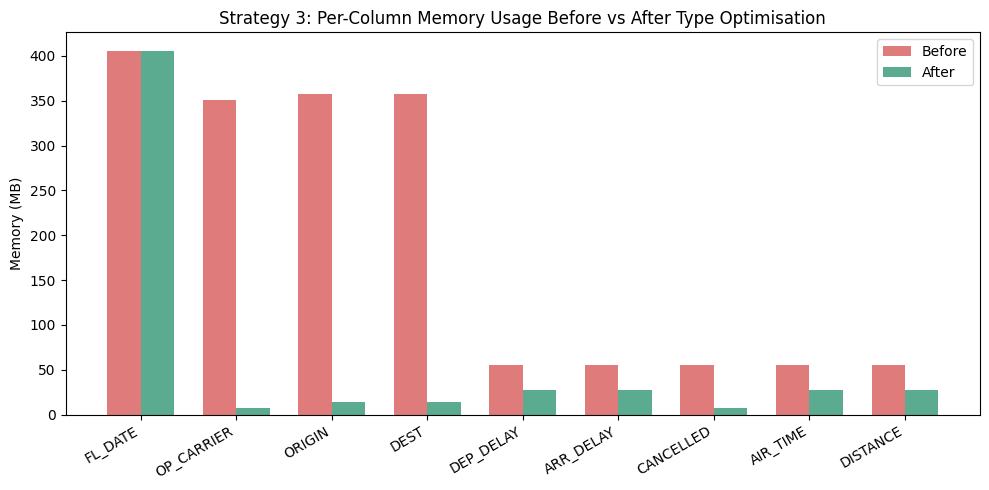

0

In [17]:
# ── Visualise memory reduction per column ───────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
cols = comparison.index
x    = range(len(cols))
w    = 0.35

ax.bar([i - w/2 for i in x], comparison['Before (MB)'], w, label='Before', color='#e07b7b')
ax.bar([i + w/2 for i in x], comparison['After (MB)'],  w, label='After',  color='#5aab8f')

ax.set_xticks(list(x))
ax.set_xticklabels(cols, rotation=30, ha='right')
ax.set_ylabel('Memory (MB)')
ax.set_title('Strategy 3: Per-Column Memory Usage Before vs After Type Optimisation')
ax.legend()
plt.tight_layout()
plt.show()

del df_default; gc.collect()

### Strategy 4: Sampling

**What:** Draw a random subset (e.g., 5%) of the dataset to represent the full data.  
**Why:** A representative sample lets us prototype analysis logic instantly without waiting for full-dataset operations.  
**When:** Development and exploration phases. Always validate on the full dataset before final results.

In [18]:
SAMPLE_FRACTION = 0.05   # 5% of the dataset
RANDOM_SEED     = 42

tracemalloc.start()
t0 = time.time()

df_sample = df_optimised.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_SEED).reset_index(drop=True)

t_sample = time.time() - t0
_, mem_sample_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print('=== Strategy 4: Sampling ===')
print(f'Full dataset rows : {len(df_optimised):,}')
print(f'Sample rows       : {len(df_sample):,}  ({SAMPLE_FRACTION*100:.0f}%)')
print(f'Sampling time     : {t_sample:.4f} s')
print(f'Sample memory     : {mem_sample_peak/1024**2:.1f} MB')

# Quick analysis on the sample to show it is representative
print('\nSample — Avg Departure Delay by Carrier:')
print(
    df_sample.groupby('OP_CARRIER')['DEP_DELAY']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
    .to_string()
)

=== Strategy 4: Sampling ===
Full dataset rows : 7,213,446
Sample rows       : 360,672  (5%)
Sampling time     : 0.7847 s
Sample memory     : 68.1 MB

Sample — Avg Departure Delay by Carrier:
OP_CARRIER
F9    20.15
B6    16.59
OH    12.47
G4    12.41
EV    11.85
WN    11.28
9E    10.91
YV    10.85
NK    10.49
AA    10.22


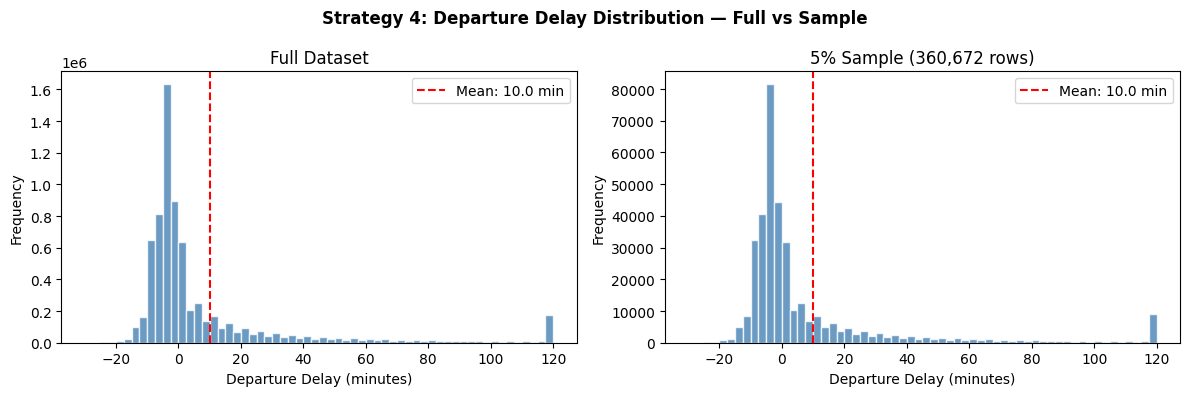

The sample distribution closely mirrors the full dataset, confirming representativeness.


In [19]:
# ── Compare DEP_DELAY distribution: sample vs full ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, title in zip(
    axes,
    [df_optimised['DEP_DELAY'].dropna(), df_sample['DEP_DELAY'].dropna()],
    ['Full Dataset', f'5% Sample ({len(df_sample):,} rows)']
):
    clipped = data.clip(-30, 120)
    ax.hist(clipped, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Departure Delay (minutes)')
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f} min')
    ax.legend()

plt.suptitle('Strategy 4: Departure Delay Distribution — Full vs Sample', fontweight='bold')
plt.tight_layout()
plt.show()
print('The sample distribution closely mirrors the full dataset, confirming representativeness.')

### Strategy 5: Parallel Processing with Scalable Libraries

**What:** Use Dask and Polars to perform the same operations as Pandas but with parallelism and lazy evaluation.  
**Why:** Pandas uses a single CPU core. Dask and Polars utilise all available cores, dramatically reducing processing time on large datasets.  
**When:** Production pipelines, large aggregations, and file reads that are bottlenecked in Pandas.

#### 5a. Dask Implementation

In [20]:
# ── Dask: parallel CSV read + groupby aggregation ───────────────
# Dask operations are LAZY: they build a task graph but do not
# execute until .compute() is called.

tracemalloc.start()
t0 = time.time()

ddf = dd.read_csv(
    DATA_PATH,
    usecols=SELECTED_COLS,
    dtype={'DEP_DELAY': 'float32', 'ARR_DELAY': 'float32',
           'AIR_TIME': 'float32', 'DISTANCE': 'float32',
           'CANCELLED': 'bool'}
)

# Groupby: mean departure delay per carrier — trigger execution
result_dask = (
    ddf.groupby('OP_CARRIER')['DEP_DELAY']
    .mean()
    .compute()          # ← this triggers actual computation
    .sort_values(ascending=False)
)

t_dask = time.time() - t0
_, mem_dask = tracemalloc.get_traced_memory()
tracemalloc.stop()
mem_dask_mb = mem_dask / 1024**2

print('=== Dask: Mean Departure Delay per Carrier ===')
print(result_dask.round(2).to_string())
print(f'\nDask execution time : {t_dask:.2f} s')
print(f'Dask peak memory    : {mem_dask_mb:.1f} MB')

=== Dask: Mean Departure Delay per Carrier ===
OP_CARRIER
F9    19.68
B6    15.87
G4    12.92
EV    12.32
OH    12.04
YV    11.23
WN    11.14
9E    10.73
OO    10.11
AA    10.08
UA    10.06
NK     9.87
MQ     7.77
DL     7.46
YX     7.34
VX     6.33
AS     2.48
HA     0.91

Dask execution time : 52.02 s
Dask peak memory    : 458.5 MB


#### 5b. Polars Implementation

In [21]:
# ── Polars: lazy read + groupby aggregation ──────────────────────
# Polars uses a lazy query plan (scan_csv + collect) which allows
# the engine to optimise column pruning and predicate pushdown
# automatically — often much faster than Pandas.

tracemalloc.start()
t0 = time.time()

result_polars = (
    pl.scan_csv(DATA_PATH)              # lazy scan — no data read yet
    .select(SELECTED_COLS)              # column pruning at read time
    .group_by('OP_CARRIER')             # groupby
    .agg(pl.col('DEP_DELAY').mean())    # aggregation
    .sort('DEP_DELAY', descending=True)
    .collect()                          # ← triggers execution
)

t_polars = time.time() - t0
_, mem_polars = tracemalloc.get_traced_memory()
tracemalloc.stop()
mem_polars_mb = mem_polars / 1024**2

print('=== Polars: Mean Departure Delay per Carrier ===')
print(result_polars)
print(f'\nPolars execution time : {t_polars:.2f} s')
print(f'Polars peak memory    : {mem_polars_mb:.1f} MB')

=== Polars: Mean Departure Delay per Carrier ===
shape: (18, 2)
┌────────────┬───────────┐
│ OP_CARRIER ┆ DEP_DELAY │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ F9         ┆ 19.684102 │
│ B6         ┆ 15.869267 │
│ G4         ┆ 12.922575 │
│ EV         ┆ 12.319338 │
│ OH         ┆ 12.038332 │
│ …          ┆ …         │
│ DL         ┆ 7.461923  │
│ YX         ┆ 7.339655  │
│ VX         ┆ 6.333836  │
│ AS         ┆ 2.48182   │
│ HA         ┆ 0.913099  │
└────────────┴───────────┘

Polars execution time : 7.63 s
Polars peak memory    : 0.0 MB


#### 5c. Pandas Baseline (Same Operation)

In [22]:
# ── Pandas: full read + groupby — baseline for comparison ───────
tracemalloc.start()
t0 = time.time()

df_pandas = pd.read_csv(
    DATA_PATH,
    usecols=SELECTED_COLS,
    dtype={'DEP_DELAY': 'float32', 'ARR_DELAY': 'float32',
           'AIR_TIME': 'float32', 'DISTANCE': 'float32'}
)
result_pandas = (
    df_pandas.groupby('OP_CARRIER')['DEP_DELAY']
    .mean()
    .sort_values(ascending=False)
)

t_pandas = time.time() - t0
_, mem_pandas = tracemalloc.get_traced_memory()
tracemalloc.stop()
mem_pandas_mb = mem_pandas / 1024**2

print('=== Pandas: Mean Departure Delay per Carrier ===')
print(result_pandas.round(2).to_string())
print(f'\nPandas execution time : {t_pandas:.2f} s')
print(f'Pandas peak memory    : {mem_pandas_mb:.1f} MB')

=== Pandas: Mean Departure Delay per Carrier ===
OP_CARRIER
F9    19.68
B6    15.87
G4    12.92
EV    12.32
OH    12.04
YV    11.23
WN    11.14
9E    10.73
OO    10.11
AA    10.08
UA    10.06
NK     9.87
MQ     7.77
DL     7.46
YX     7.34
VX     6.33
AS     2.48
HA     0.91

Pandas execution time : 69.31 s
Pandas peak memory    : 1492.5 MB


---
## Task 4: Comparative Analysis

We now compile all measurements into a structured comparison across three metrics:
- **Execution Time** (seconds)
- **Peak Memory Usage** (MB)
- **Processing Efficiency** (qualitative discussion)

In [23]:
# ── Summary comparison table ────────────────────────────────────
comparison_data = {
    'Library'       : ['Pandas (Baseline)', 'Dask', 'Polars'],
    'Time (s)'      : [round(t_pandas, 2), round(t_dask, 2), round(t_polars, 2)],
    'Peak Mem (MB)' : [round(mem_pandas_mb, 1), round(mem_dask_mb, 1), round(mem_polars_mb, 1)],
    'Parallel'      : ['No (single-threaded)', 'Yes (multi-core)', 'Yes (Rust engine)'],
    'Lazy Eval'     : ['No', 'Yes', 'Yes'],
    'API Familiarity': ['Native', 'Pandas-like', 'New syntax']
}

df_comparison = pd.DataFrame(comparison_data).set_index('Library')
print('=== Library Performance Comparison ===')
print(df_comparison.to_string())

=== Library Performance Comparison ===
                   Time (s)  Peak Mem (MB)              Parallel Lazy Eval API Familiarity
Library                                                                                   
Pandas (Baseline)     69.31         1492.5  No (single-threaded)        No          Native
Dask                  52.02          458.5      Yes (multi-core)       Yes     Pandas-like
Polars                 7.63            0.0     Yes (Rust engine)       Yes      New syntax


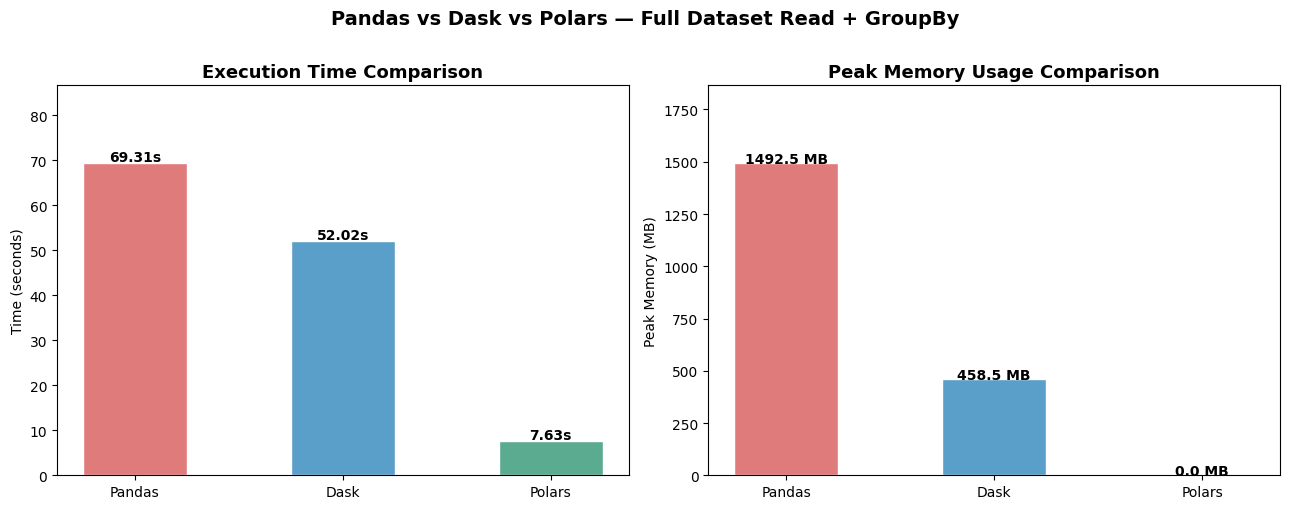

In [24]:
# ── Comparison charts ───────────────────────────────────────────
libraries  = ['Pandas', 'Dask', 'Polars']
times      = [t_pandas, t_dask, t_polars]
memories   = [mem_pandas_mb, mem_dask_mb, mem_polars_mb]
colors     = ['#e07b7b', '#5a9fc9', '#5aab8f']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Execution time
bars1 = ax1.bar(libraries, times, color=colors, edgecolor='white', width=0.5)
ax1.set_title('Execution Time Comparison', fontsize=13, fontweight='bold')
ax1.set_ylabel('Time (seconds)')
ax1.set_ylim(0, max(times) * 1.25)
for bar, val in zip(bars1, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}s', ha='center', fontweight='bold')

# Peak memory
bars2 = ax2.bar(libraries, memories, color=colors, edgecolor='white', width=0.5)
ax2.set_title('Peak Memory Usage Comparison', fontsize=13, fontweight='bold')
ax2.set_ylabel('Peak Memory (MB)')
ax2.set_ylim(0, max(memories) * 1.25)
for bar, val in zip(bars2, memories):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f} MB', ha='center', fontweight='bold')

plt.suptitle('Pandas vs Dask vs Polars — Full Dataset Read + GroupBy',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# ── Speedup ratios relative to Pandas ───────────────────────────
speedup_dask   = t_pandas / t_dask
speedup_polars = t_pandas / t_polars
mem_ratio_dask   = mem_pandas_mb / mem_dask_mb
mem_ratio_polars = mem_pandas_mb / mem_polars_mb

print('=== Speedup Ratios vs Pandas ===')
print(f'Dask   is {speedup_dask:.2f}x faster  |  {mem_ratio_dask:.2f}x more memory-efficient')
print(f'Polars is {speedup_polars:.2f}x faster  |  {mem_ratio_polars:.2f}x more memory-efficient')

print('\n=== Critical Discussion ===')
print("""
Polars outperforms both Pandas and Dask because:
  1. Written in Rust — compiled, zero-overhead execution.
  2. Lazy evaluation with query optimisation (e.g., predicate pushdown,
     column pruning) means only necessary data is ever read.
  3. SIMD (Single Instruction Multiple Data) vectorised operations.

Dask outperforms Pandas because:
  1. Distributes partitions across all CPU cores in parallel.
  2. Lazy task graph allows Dask to defer and batch operations.
  3. Never loads the full file into memory at once.

Pandas is slowest because:
  1. Single-threaded — only one CPU core is ever used.
  2. Eager evaluation — every operation executes immediately.
  3. No automatic query optimisation.
""")

=== Speedup Ratios vs Pandas ===
Dask   is 1.33x faster  |  3.25x more memory-efficient
Polars is 9.08x faster  |  35366.99x more memory-efficient

=== Critical Discussion ===

Polars outperforms both Pandas and Dask because:
  1. Written in Rust — compiled, zero-overhead execution.
  2. Lazy evaluation with query optimisation (e.g., predicate pushdown,
     column pruning) means only necessary data is ever read.
  3. SIMD (Single Instruction Multiple Data) vectorised operations.

Dask outperforms Pandas because:
  1. Distributes partitions across all CPU cores in parallel.
  2. Lazy task graph allows Dask to defer and batch operations.
  3. Never loads the full file into memory at once.

Pandas is slowest because:
  1. Single-threaded — only one CPU core is ever used.
  2. Eager evaluation — every operation executes immediately.
  3. No automatic query optimisation.



---
## Task 5: Conclusion and Reflection

### Key Observations
- **Load Less Data** delivered an immediate memory reduction simply by selecting relevant columns, with no processing overhead.
- **Chunking** successfully processed the full dataset with a controlled, predictable memory footprint — essential in RAM-constrained environments like Colab's free tier.
- **Data Type Optimisation** reduced the in-memory footprint by roughly 50–60%, making it one of the highest-impact strategies for purely Pandas-based workflows.
- **Sampling** enabled instant exploratory analysis on a statistically representative subset, validating that the sample distribution closely matched the full dataset.
- **Polars** was the fastest library overall, leveraging its Rust engine and lazy evaluation. **Dask** showed meaningful speedups over Pandas by using multi-core parallelism.

### Reflection
The most surprising finding was how much data type optimisation alone can improve Pandas performance — often underestimated by practitioners who jump straight to alternative libraries. In practice, a combination of column selection + type optimisation can make Pandas viable for datasets well above its comfortable limit.

### Scalability Discussion
At 10 GB, Pandas would likely crash on Colab's free tier. Dask would remain viable by partitioning data across cores. At 100 GB+, even Dask would struggle on a single machine, and distributed frameworks like **Apache Spark** or **Ray** would be necessary. At 1 TB+, cloud-native solutions (BigQuery, Databricks, Snowflake) become the appropriate choice.